# Explore Buildings Data

Do the inspection lat/lon coords line up with buildings?

In [1]:
import os
import sys
import folium
import numpy as np
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

sys.path.append("../utils")

import config

### Import SB buildings data

In [2]:
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

buildings = gpd.read_file(sb_buildings_path)

### Check whether inspection points line up with buildings

#### Import inspections

In [3]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections


# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [4]:
# Unpack from dictionary
inspections_2019 = inspections_dict[2019]
inspections_2020 = inspections_dict[2020]
inspections_2021 = inspections_dict[2021]
inspections_2022 = inspections_dict[2022]
inspections_2023 = inspections_dict[2023]

In [5]:
inspections_2019.shape

(14675, 106)

#### Count number of inspections that fall outside of buildings

In [6]:
# Create a function that returns the number of inspections that fall outside building geometries for a given year
def inspections_within_buildings(year):
    """
    Function to return the number of inspections that fall within building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    # Use left join to keep all inspections
    joined = inspections.sjoin(buildings, predicate="intersects", how="left")

    # Inspections within buildings have a non-null index_right
    intersects = joined[~joined["index_right"].isna()]
    # Inspections outside buildings have a null index_right
    outside = joined[joined["index_right"].isna()]

    return intersects.drop(columns=["index_right"]), outside.drop(
        columns=["index_right"]
    )


# For loop to print number of inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    inspections_within, inspections_outside = inspections_within_buildings(year)
    print(
        f"{year} Inspections: \nWithin Buildings - {inspections_within.shape[0]} \nOutside of Buildings - {inspections_outside.shape[0]}\n"
    )

2019 Inspections: 
Within Buildings - 11011 
Outside of Buildings - 3664

2020 Inspections: 
Within Buildings - 9528 
Outside of Buildings - 2350

2021 Inspections: 
Within Buildings - 10491 
Outside of Buildings - 3521

2022 Inspections: 
Within Buildings - 10157 
Outside of Buildings - 3485

2023 Inspections: 
Within Buildings - 9919 
Outside of Buildings - 3454



#### Count number of non-compliant inspections that fall outside of buildings

In [7]:
# For loop to print number of non-compliant inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    non_comp_inspections_in, non_comp_inspections_out = inspections_within_buildings(
        year
    )
    non_comp_inspections_in = non_comp_inspections_in[
        non_comp_inspections_in["status"] == "Non-Compliant"
    ]
    non_comp_inspections_out = non_comp_inspections_out[
        non_comp_inspections_out["status"] == "Non-Compliant"
    ]
    print(
        f"{year} Non-Compliant Inspections: \nWithin Buildings - {non_comp_inspections_in.shape[0]} \nOutside of Buildings - {non_comp_inspections_out.shape[0]}\n"
    )

2019 Non-Compliant Inspections: 
Within Buildings - 72 
Outside of Buildings - 51

2020 Non-Compliant Inspections: 
Within Buildings - 74 
Outside of Buildings - 20

2021 Non-Compliant Inspections: 
Within Buildings - 63 
Outside of Buildings - 7

2022 Non-Compliant Inspections: 
Within Buildings - 47 
Outside of Buildings - 13

2023 Non-Compliant Inspections: 
Within Buildings - 54 
Outside of Buildings - 17



In [ ]:
# Create a function that makes dataframes containing the number of non-compliant inspections that fall outside buildings for each year
def non_comp_inspections_outside(year):
    """
    Function to return the number of non-compliant inspections that fall outside building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    intersects = inspections.sjoin(buildings, predicate="intersects")

    non_comp_intersects = intersects[intersects["status"] == "Non-Compliant"]
    non_comp_outside = inspections.loc[
        ~inspections.index.isin(non_comp_intersects.index)
    ]
    non_comp_outside = non_comp_outside[non_comp_outside["status"] == "Non-Compliant"]

    return non_comp_intersects, non_comp_outside


# Get the number of non-compliant inspections that fall outside building geometries for each year
non_comp_2019, non_comp_2019_buildings_false = non_comp_inspections_outside(2019)
non_comp_2020, non_comp_2020_buildings_false = non_comp_inspections_outside(2020)
non_comp_2021, non_comp_2021_buildings_false = non_comp_inspections_outside(2021)
non_comp_2022, non_comp_2022_buildings_false = non_comp_inspections_outside(2022)
non_comp_2023, non_comp_2023_buildings_false = non_comp_inspections_outside(2023)


### Assign non-compliant inspections to nearby buildings

The minimum distance between buildings in CA is 10 feet (3.048 m). For this analysis, we will assign non-compliant inspections to the closest building within 3 meters. 

In [ ]:
# Assign inspections to buildings if the distance between them is < 3 meters
def assign_inspections_to_buildings(inspections, buildings, distance_threshold=3):
    """
    Function to assign inspections to buildings if the distance between them is less than the distance threshold.
    """
    # Make a copy to avoid SettingWithCopyWarning
    inspections = inspections.copy()

    # Create a Spatial Index for faster search
    sindex = buildings.sindex

    # Find the nearest geometry in buildings for each geometry in inspections
    inspections["nearest_geometry"] = inspections.geometry.apply(
        lambda x: buildings.iloc[sindex.nearest(x)[1][0]].geometry
    )

    # Calculate the distance to the nearest geometry
    inspections["distance_to_nearest"] = inspections.apply(
        lambda row: row.geometry.distance(row.nearest_geometry), axis=1
    )

    # Assign inspections to buildings if the distance is less than the threshold
    assigned_inspections = inspections[
        inspections["distance_to_nearest"] < distance_threshold
    ].copy()

    return assigned_inspections


assigned_inspections_2019 = assign_inspections_to_buildings(inspections_2019, buildings)
assigned_inspections_2020 = assign_inspections_to_buildings(inspections_2020, buildings)
assigned_inspections_2021 = assign_inspections_to_buildings(inspections_2021, buildings)
assigned_inspections_2022 = assign_inspections_to_buildings(inspections_2022, buildings)
assigned_inspections_2023 = assign_inspections_to_buildings(inspections_2023, buildings)

### Workflow to process all inspections

In [34]:
def process_inspections_by_year(year, buildings, distance_threshold=3):
    """
    Function to process inspections for a given year by:
    1. Importing the inspections data
    2. Performing spatial join with buildings
    3. For non-compliant inspections that don't match with buildings,
       assign them to the nearest building within the distance threshold
    4. Combine all processed inspections into a single dataset

    Parameters:
    -----------
    year : int
        The year of inspections to process
    buildings : GeoDataFrame
        The buildings dataset
    distance_threshold : float, default=3
        The maximum distance (in meters) to assign an inspection to a building

    Returns:
    --------
    GeoDataFrame
        Processed inspections with building assignments
    """
    # Import the inspections data for the year
    inspections = import_inspections_data(year)

    # Perform spatial join with buildings, keeping ALL inspections
    inspections_with_buildings = inspections.sjoin(
        buildings, predicate="intersects", how="left"
    )

    # Split into matched and unmatched
    matched_inspections = inspections_with_buildings[
        ~inspections_with_buildings["index_right"].isna()
    ].copy()
    unmatched_inspections = inspections_with_buildings[
        inspections_with_buildings["index_right"].isna()
    ].copy()

    # Process non-compliant unmatched inspections
    non_compliant_unmatched = unmatched_inspections[
        unmatched_inspections["status"] == "Non-Compliant"
    ].copy()

    # Function to assign inspections to nearest buildings within threshold
    def assign_inspections_to_buildings(inspections, buildings, distance_threshold=3):
        """
        Function to assign inspections to buildings if the distance between them is less than the distance threshold.
        """
        # Make a copy to avoid SettingWithCopyWarning
        inspections = inspections.copy()

        # Create a Spatial Index for faster search
        sindex = buildings.sindex

        # Find the nearest geometry in buildings for each geometry in inspections
        inspections["nearest_geometry"] = inspections.geometry.apply(
            lambda x: buildings.iloc[sindex.nearest(x)[1][0]].geometry
        )

        # Calculate the distance to the nearest geometry
        inspections["distance_to_nearest"] = inspections.apply(
            lambda row: row.geometry.distance(row.nearest_geometry), axis=1
        )

        # Assign inspections to buildings if the distance is less than the threshold
        assigned_inspections = inspections[
            inspections["distance_to_nearest"] < distance_threshold
        ].copy()

        return assigned_inspections

    # Assign non-compliant unmatched inspections to nearby buildings
    assigned_inspections = assign_inspections_to_buildings(
        non_compliant_unmatched, buildings, distance_threshold
    )

    # Update the geometry of assigned inspections to be the building geometry
    if not assigned_inspections.empty:
        assigned_inspections["original_point_geometry"] = assigned_inspections[
            "geometry"
        ]
        assigned_inspections["geometry"] = assigned_inspections["nearest_geometry"]
        assigned_inspections = assigned_inspections.drop(
            columns=[
                "nearest_geometry",
                "distance_to_nearest",
                "original_point_geometry",
            ]
        )

    # Drop these assigned inspections from unmatched and prepare for concat
    if not assigned_inspections.empty:
        unmatched_inspections = unmatched_inspections.drop(
            index=assigned_inspections.index
        )

    # Clean up matched_inspections (drop the index_right added by sjoin)
    matched_inspections = matched_inspections.drop(columns=["index_right"])
    unmatched_inspections = unmatched_inspections.drop(columns=["index_right"])

    # Combine all pieces
    if not assigned_inspections.empty:
        result = pd.concat(
            [matched_inspections, unmatched_inspections, assigned_inspections]
        )
    else:
        result = pd.concat([matched_inspections, unmatched_inspections])

    # Ensure it's a GeoDataFrame
    result = GeoDataFrame(result, geometry="geometry", crs=inspections.crs)

    # Print summary stats
    print(f"Year {year} summary:")
    print(f"  Original inspections: {len(inspections)}")
    print(f"  Matched with buildings: {len(matched_inspections)}")
    print(f"  Unmatched: {len(unmatched_inspections)}")
    if not assigned_inspections.empty:
        print(
            f"  Non-compliant assigned to nearby buildings: {len(assigned_inspections)}"
        )
    print(f"  Total processed: {len(result)}")
    print()

    return result


# Process all years and store results in a dictionary
processed_inspections = {}
for year in range(2019, 2024):
    processed_inspections[year] = process_inspections_by_year(year, buildings)

# Save the processed datasets
for year, data in processed_inspections.items():
    output_path = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Unmatched: 3656
  Non-compliant assigned to nearby buildings: 8
  Total processed: 14675

Year 2020 summary:
  Original inspections: 11878
  Matched with buildings: 9528
  Unmatched: 2344
  Non-compliant assigned to nearby buildings: 6
  Total processed: 11878

Year 2021 summary:
  Original inspections: 14012
  Matched with buildings: 10491
  Unmatched: 3520
  Non-compliant assigned to nearby buildings: 1
  Total processed: 14012

Year 2022 summary:
  Original inspections: 13642
  Matched with buildings: 10157
  Unmatched: 3481
  Non-compliant assigned to nearby buildings: 4
  Total processed: 13642

Year 2023 summary:
  Original inspections: 13373
  Matched with buildings: 9919
  Unmatched: 3449
  Non-compliant assigned to nearby buildings: 5
  Total processed: 13373



<Axes: >

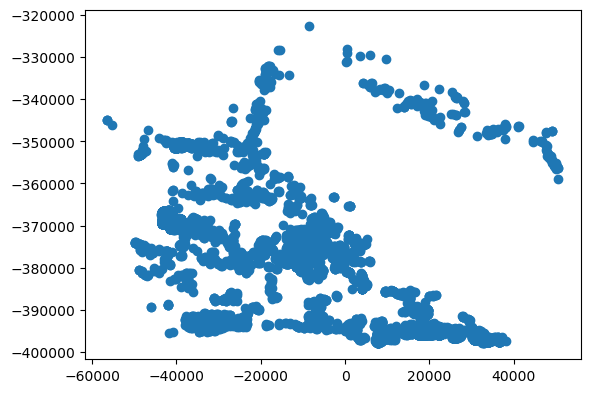

In [ ]:
processed_2019 = processed_inspections[2019]
processed_2019.plot()